# [실습 8-2] PCA로 MNIST 시각화 — 784차원을 2차원 지도에 펼치기

| 항목 | 내용 |
|---|---|
| 예상 소요 시간 | 30~40분 (CPU 충분) |
| 본문 연계 | 8.3 차원 축소 |
| 선수 실습 | [실습 8-1] (권장) |
| 준비 | 부록 B.1·B.3 참고. 최초 실행 시 MNIST 다운로드(약 11MB) |

손글씨 숫자 이미지 5,000장(각 784차원)을 주성분 2개의
평면에 투영해 **"같은 데이터, 다른 표현"**(장 Before/After 축)을
직접 확인한다.

### [준비] 환경 설정 (저장소 전용)

In [1]:
# 저장소 루트를 임포트 경로에 추가
# (Colab에서는 아래 두 줄의 주석을 해제하고 실행)
# !git clone https://github.com/tbgoodlife/ai-labs.git
# %cd ai-labs
import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "utils").exists():
    ROOT = ROOT.parent          # ch08/에서 연 경우
sys.path.insert(0, str(ROOT))

import platform
import numpy as np
import sklearn
import matplotlib.pyplot as plt
from utils import plot_style, viz

plot_style.apply()              # 도해 스타일 킷 적용
print("Python", platform.python_version())
print("NumPy", np.__version__,
      "/ scikit-learn", sklearn.__version__)

from utils.data import load_mnist

Python 3.12.6
NumPy 2.4.6 / scikit-learn 1.9.0


### [셀 1] 워밍업 — 붓꽃 4차원을 2차원으로 📖

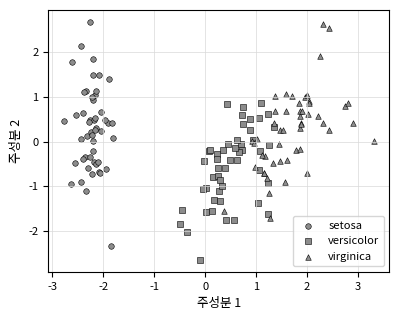

In [2]:
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

iris = load_iris()
Z = PCA(2).fit_transform(
    StandardScaler().fit_transform(iris.data))

fig, ax = plt.subplots(figsize=(4.4, 3.4))
for k, marker in zip(range(3), ["o", "s", "^"]):
    pts = Z[iris.target == k]
    ax.scatter(pts[:, 0], pts[:, 1], s=16,
               marker=marker, color="#8c8c8c",
               edgecolor="black", linewidth=.4,
               label=str(iris.target_names[k]))
ax.set_xlabel("주성분 1")
ax.set_ylabel("주성분 2")
ax.legend()
plt.show()

**핵심 포인트**
- 특징 4개(길이·너비 2쌍)가 축 2개로 줄었는데도 세 품종이 갈라져 보인다 — 데이터의 "**가장 크게 벌어진 방향**"(주성분)만 남긴 결과(8.3 PCA의 축 회전·투영).
- 품종 라벨은 그림 해석용일 뿐, PCA 계산에는 **쓰이지 않았다**(비지도).

### [셀 2] MNIST 로드 — 784차원 데이터 📖

형태: (5000, 784) — 이미지 한 장 = 784 차원 벡터


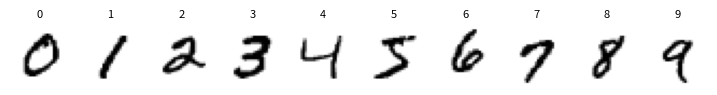

In [3]:
# 8·9장 공용 로더(utils/data.py) — 9장에서 같은
# 데이터를 다시 만난다
(x, y), _ = load_mnist(n=5000, flatten=True)
print("형태:", x.shape, "— 이미지 한 장 =",
      x.shape[1], "차원 벡터")

fig, axes = plt.subplots(1, 10, figsize=(9, 1.2))
for d, ax in enumerate(axes):
    ax.imshow(x[y == d][0].reshape(28, 28),
              cmap="gray_r")
    ax.set_title(str(d), fontsize=8)
    ax.axis("off")
plt.show()

**핵심 포인트**
- 28×28 이미지 한 장이 곧 **784차원 공간의 점 하나**다 — 사람은 3차원 너머를 볼 수 없으므로, 보려면 줄여야 한다.
- `load_mnist(n=5000)`: 전체 6만 장 중 앞 5,000장 부분 표본 — 시각화·계산이 가볍다.

실패 시 대처: 최초 실행 시 다운로드 지연은 정상(Colab 캐시로 재실행은 즉시).

### [셀 3] Before/After — 원시 픽셀 축 vs 주성분 축 📖

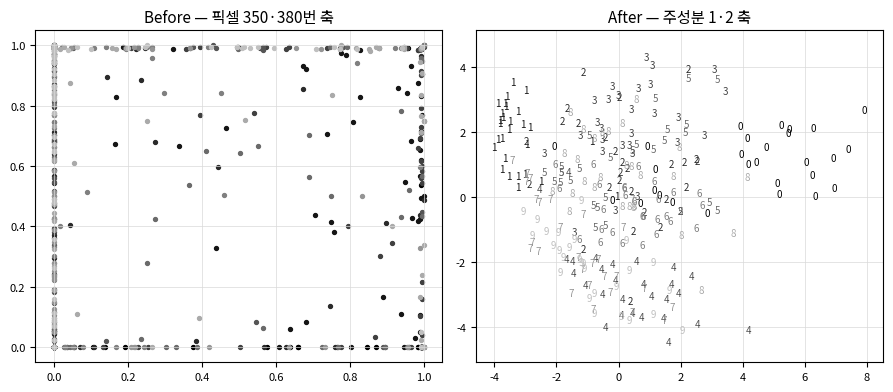

In [4]:
pca = PCA(2).fit(x)
Z = pca.transform(x)
sub = np.arange(0, 5000, 7)     # 표시용 부분 표본

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
grays = plt.cm.gray(np.linspace(0, 0.75, 10))
for d in range(10):
    m = sub[y[sub] == d]
    axes[0].scatter(x[m, 350], x[m, 380], s=8,
                    color=grays[d])
    axes[1].scatter(Z[m, 0], Z[m, 1], s=0)
    for i in m[:28]:
        axes[1].text(Z[i, 0], Z[i, 1], str(d),
                     fontsize=7, color=grays[d],
                     ha="center", va="center")
axes[0].set_title("Before — 픽셀 350·380번 축")
axes[1].set_title("After — 주성분 1·2 축")
plt.tight_layout()
plt.show()

**핵심 포인트**
- **Before**: 아무 픽셀 2개를 축으로 삼으면 숫자들이 완전히 뒤엉킨다 — 좌표 하나하나는 정보가 거의 없다.
- **After**: 같은 데이터를 주성분 2축으로 보면 0과 1이 양끝으로 갈라지고 무리가 드러난다. 다만 4·9처럼 생김새가 비슷한 숫자는 여전히 겹친다 — **선형 압축의 힘과 한계**를 동시에 본다(비선형 축소는 [보조 1]).
- 그림이 좌우/상하 반전되어 보여도 정상이다(주성분의 부호는 임의적 — 수학적으로 동등).

### [셀 4] 누적 설명 분산 — 몇 차원이면 충분한가 📖

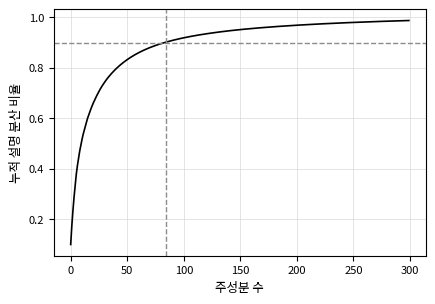

분산 90% 보존에 84개, 95%에 148개 주성분이면 충분 (원본 784)


In [5]:
pca_full = PCA().fit(x)
cum = np.cumsum(pca_full.explained_variance_ratio_)
n90 = int(np.argmax(cum >= 0.90)) + 1
n95 = int(np.argmax(cum >= 0.95)) + 1

fig, ax = plt.subplots(figsize=(4.8, 3.2))
ax.plot(cum[:300], color="black", lw=1.2)
ax.axhline(0.90, color="#8c8c8c", ls="--", lw=1)
ax.axvline(n90, color="#8c8c8c", ls="--", lw=1)
ax.set_xlabel("주성분 수")
ax.set_ylabel("누적 설명 분산 비율")
plt.show()
print(f"분산 90% 보존에 {n90}개, "
      f"95%에 {n95}개 주성분이면 충분 (원본 784)")

**핵심 포인트**
- 784차원 중 **주성분 수십 개**가 분산의 90%를 설명한다 — "본질만 남기고 압축"의 수치적 근거.
- 안전한 시작값: 시각화는 2~3, 전처리 압축은 누적 90~95% 지점(8.3 PCA 처방).

기대 출력: 90%에 약 80~90개, 95%에 약 150개.

### [보조 1] t-SNE 체험 — 비선형 지도 제작 (8.3)

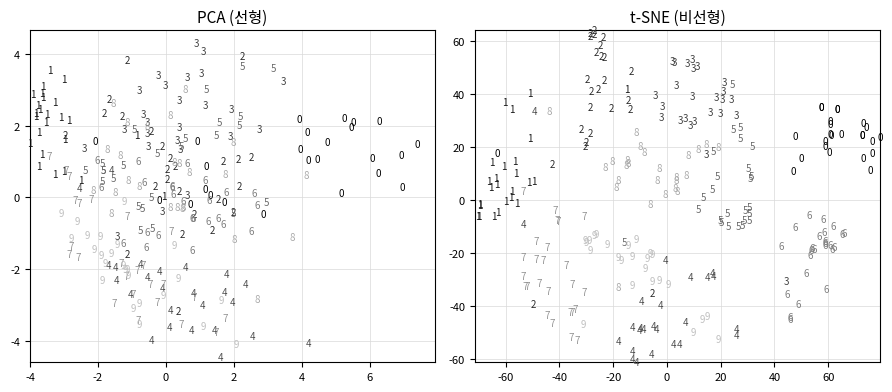

In [6]:
from sklearn.manifold import TSNE

# 관례: PCA로 50차원까지 줄인 뒤 t-SNE(속도·안정성)
x50 = PCA(50, random_state=42).fit_transform(x)
Z2 = TSNE(2, random_state=42,
          init="pca").fit_transform(x50)

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for d in range(10):
    m = sub[y[sub] == d]
    for Zk, ax in [(Z, axes[0]), (Z2, axes[1])]:
        for i in m[:25]:
            ax.text(Zk[i, 0], Zk[i, 1], str(d),
                    fontsize=7, color=grays[d],
                    ha="center", va="center")
    axes[0].set_title("PCA (선형)")
    axes[1].set_title("t-SNE (비선형)")
for ax, Zk in [(axes[0], Z), (axes[1], Z2)]:
    ax.set_xlim(Zk[sub, 0].min(), Zk[sub, 0].max())
    ax.set_ylim(Zk[sub, 1].min(), Zk[sub, 1].max())
plt.tight_layout()
plt.show()

t-SNE에서는 10개 숫자가 훨씬 뚜렷한 **섬**으로 갈라진다 — 지구본을 평면 지도로 만들 때처럼 이웃 관계를 지키는 대신 전역 거리는 왜곡한다(8.3 t-SNE의 "지도 제작" 관점). 수 분이 걸리는 것이 정상이며, 그래서 5,000장 표본을 쓴다.

### [보조 2] 주성분 수별 이미지 재구성 — 압축했다 복원해 보기

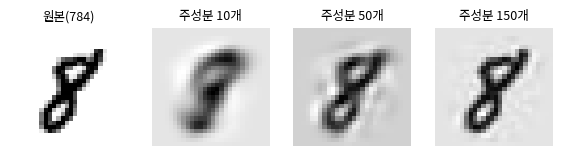

In [7]:
digit = x[y == 8][0]
fig, axes = plt.subplots(1, 4, figsize=(7, 2))
axes[0].imshow(digit.reshape(28, 28), cmap="gray_r")
axes[0].set_title("원본(784)", fontsize=9)
for ax, k in zip(axes[1:], [10, 50, 150]):
    p = PCA(k).fit(x)
    rec = p.inverse_transform(p.transform([digit]))[0]
    ax.imshow(rec.reshape(28, 28), cmap="gray_r")
    ax.set_title(f"주성분 {k}개", fontsize=9)
for ax in axes:
    ax.axis("off")
plt.show()

주성분 10개로도 "8"의 골격이 남는다 — 압축이 곧 **본질 추출**임을 눈으로 확인한다. "압축했다 복원해 보면 본질을 배운다"는 이 아이디어가 8.5 오토인코더로 이어진다.

### [심화 1] 축소 차원 결정 실험 (연습문제 응용~심화 연계)

In [8]:
# TODO: 보존 기준을 80/90/95/99%로 바꿔 가며
#       필요한 주성분 수와 [보조 2] 복원 품질을
#       함께 기록하고, "몇 %가 적정한가"를
#       용도(시각화/전처리/압축 저장)별로 논증하자.
for th in [0.80, 0.90, 0.95, 0.99]:
    n = int(np.argmax(cum >= th)) + 1
    print(f"{th:.0%} 보존 → 주성분 {n:3d}개 "
          f"(압축률 {784 / n:.0f}배)")

80% 보존 → 주성분  43개 (압축률 18배)
90% 보존 → 주성분  84개 (압축률 9배)
95% 보존 → 주성분 148개 (압축률 5배)
99% 보존 → 주성분 322개 (압축률 2배)


---
## 마무리

- PCA는 "가장 크게 벌어진 방향"을 새 축으로 삼는 **선형** 차원 축소다 — 시각화(2축)와 압축(누적 분산 기준) 두 용도를 모두 실습했다.
- 같은 데이터도 표현(축)에 따라 구조가 보이기도, 숨기도 한다 — 장의 Before/After 축 그대로.
- **여기서 뭉쳐 보던 5,000장의 숫자들 — 9장 실습 9-2에서 같은 `load_mnist` 로더로 다시 불러, 이번에는 라벨을 붙여 학습한다**("같은 데이터, 표현 → 학습").

**연습문제 연계**: [응용] 설명 분산 표로 축소 차원 결정·근거 서술은 [셀 4]·[심화 1]에서, [심화] 표현학습 논증의 체험 근거는 [보조 2]가 제공한다.

**다음 장 실습**: [실습 9-1] NumPy 퍼셉트론 (`ch09/lab-09-01_perceptron-xor.ipynb`)